# **I.IMPORT DATA**

In [ ]:
# Import các thư viện
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

Mounted at /content/drive


In [ ]:
# Tải và đọc bộ dữ liệu
df=pd.read_csv('/content/drive/My Drive/dropout_dataset_final.csv')
data = df.copy()
# Hiển thị 5 dòng đầu tiên của dữ liệu
df.head()

,learner_id,gender,learning_mode,device_type,login_frequency,resource_access_count,avg_session_duration,forum_participation,assignment_completion_rate,quiz_completion_rate,inactivity_period,avg_quiz_score,late_submission_rate,age,employment_status,learning_pattern,dropout
0,H0001,Nam,Tự học,Máy tính bảng,7.448474,29,75.592809,7,70.980378,87.002316,25,76.474338,2.330537,49,1,0,0
1,H0002,Nữ,Tự học,Điện thoại,15.798234,12,94.330348,18,89.254519,1.954311,18,61.269420,1.964830,27,2,1,0
2,H0003,Nam,Học theo nhóm,Máy tính bảng,0.786390,14,95.988471,9,69.078629,41.999831,19,8.073264,43.684065,51,2,1,1
3,H0004,Nam,Tự học,Máy tính bảng,8.635351,19,102.121509,32,41.662303,96.041406,26,11.858173,92.420582,22,0,1,1
4,H0005,Nam,Học theo nhóm,Điện thoại,7.645118,33,31.999654,36,51.366122,17.716174,22,48.119323,76.811934,37,0,1,1


In [ ]:
# Xem kiểu dữ liệu
df.dtypes

,0
learner_id,object
gender,object
learning_mode,object
device_type,object
login_frequency,float64
resource_access_count,int64
avg_session_duration,float64
forum_participation,int64
assignment_completion_rate,float64
quiz_completion_rate,float64


In [ ]:
# Thống kê mô tả
df.describe().T

,count,mean,std,min,25%,50%,75%,max
login_frequency,9000.0,10.199153,5.751323,0.000962,5.306310,10.295897,15.077077,19.998020
resource_access_count,9000.0,49.923667,28.851642,0.000000,25.000000,50.500000,75.000000,100.000000
avg_session_duration,9000.0,59.789202,34.653519,0.000664,29.658217,59.857668,89.495813,119.974725
forum_participation,9000.0,24.910667,14.761452,0.000000,12.000000,25.000000,38.000000,50.000000
assignment_completion_rate,9000.0,50.352716,28.629534,0.012895,25.864844,50.205373,75.133187,99.986154
quiz_completion_rate,9000.0,50.396221,28.995488,0.004754,25.325474,50.342957,75.900450,99.989504
inactivity_period,9000.0,15.122778,8.969329,0.000000,7.000000,15.000000,23.000000,30.000000
avg_quiz_score,9000.0,49.801464,29.072514,0.014594,24.743473,49.366630,75.213663,99.989292
late_submission_rate,9000.0,50.080333,28.709926,0.027962,25.471450,49.788782,74.766844,99.970346
age,9000.0,38.974333,12.342039,18.000000,28.000000,39.000000,50.000000,60.000000


# **II.DATA CLEANING**

In [ ]:
# Kiểm tra dữ liệu thiếu
print("\nKiểm tra giá trị thiếu:")
print(df.isnull().sum())


Kiểm tra giá trị thiếu:
learner_id                    0
gender                        0
learning_mode                 0
device_type                   0
login_frequency               0
resource_access_count         0
avg_session_duration          0
forum_participation           0
assignment_completion_rate    0
quiz_completion_rate          0
inactivity_period             0
avg_quiz_score                0
late_submission_rate          0
age                           0
employment_status             0
learning_pattern              0
dropout                       0
dtype: int64


In [ ]:
#Kiểm tra dữ liệu trùng lặp
duplicate_count = df.duplicated().sum()
print(f"Số dòng bị trùng lặp: {duplicate_count}")

Số dòng bị trùng lặp: 0


In [ ]:
# Kiểm tra giá trị ngoại lai
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
numerical_cols = numerical_cols.drop(['dropout'])
print("Các cột số:")
print(numerical_cols)

Các cột số:
Index(['login_frequency', 'resource_access_count', 'avg_session_duration',
       'forum_participation', 'assignment_completion_rate',
       'quiz_completion_rate', 'inactivity_period', 'avg_quiz_score',
       'late_submission_rate', 'age', 'employment_status', 'learning_pattern'],
      dtype='object')


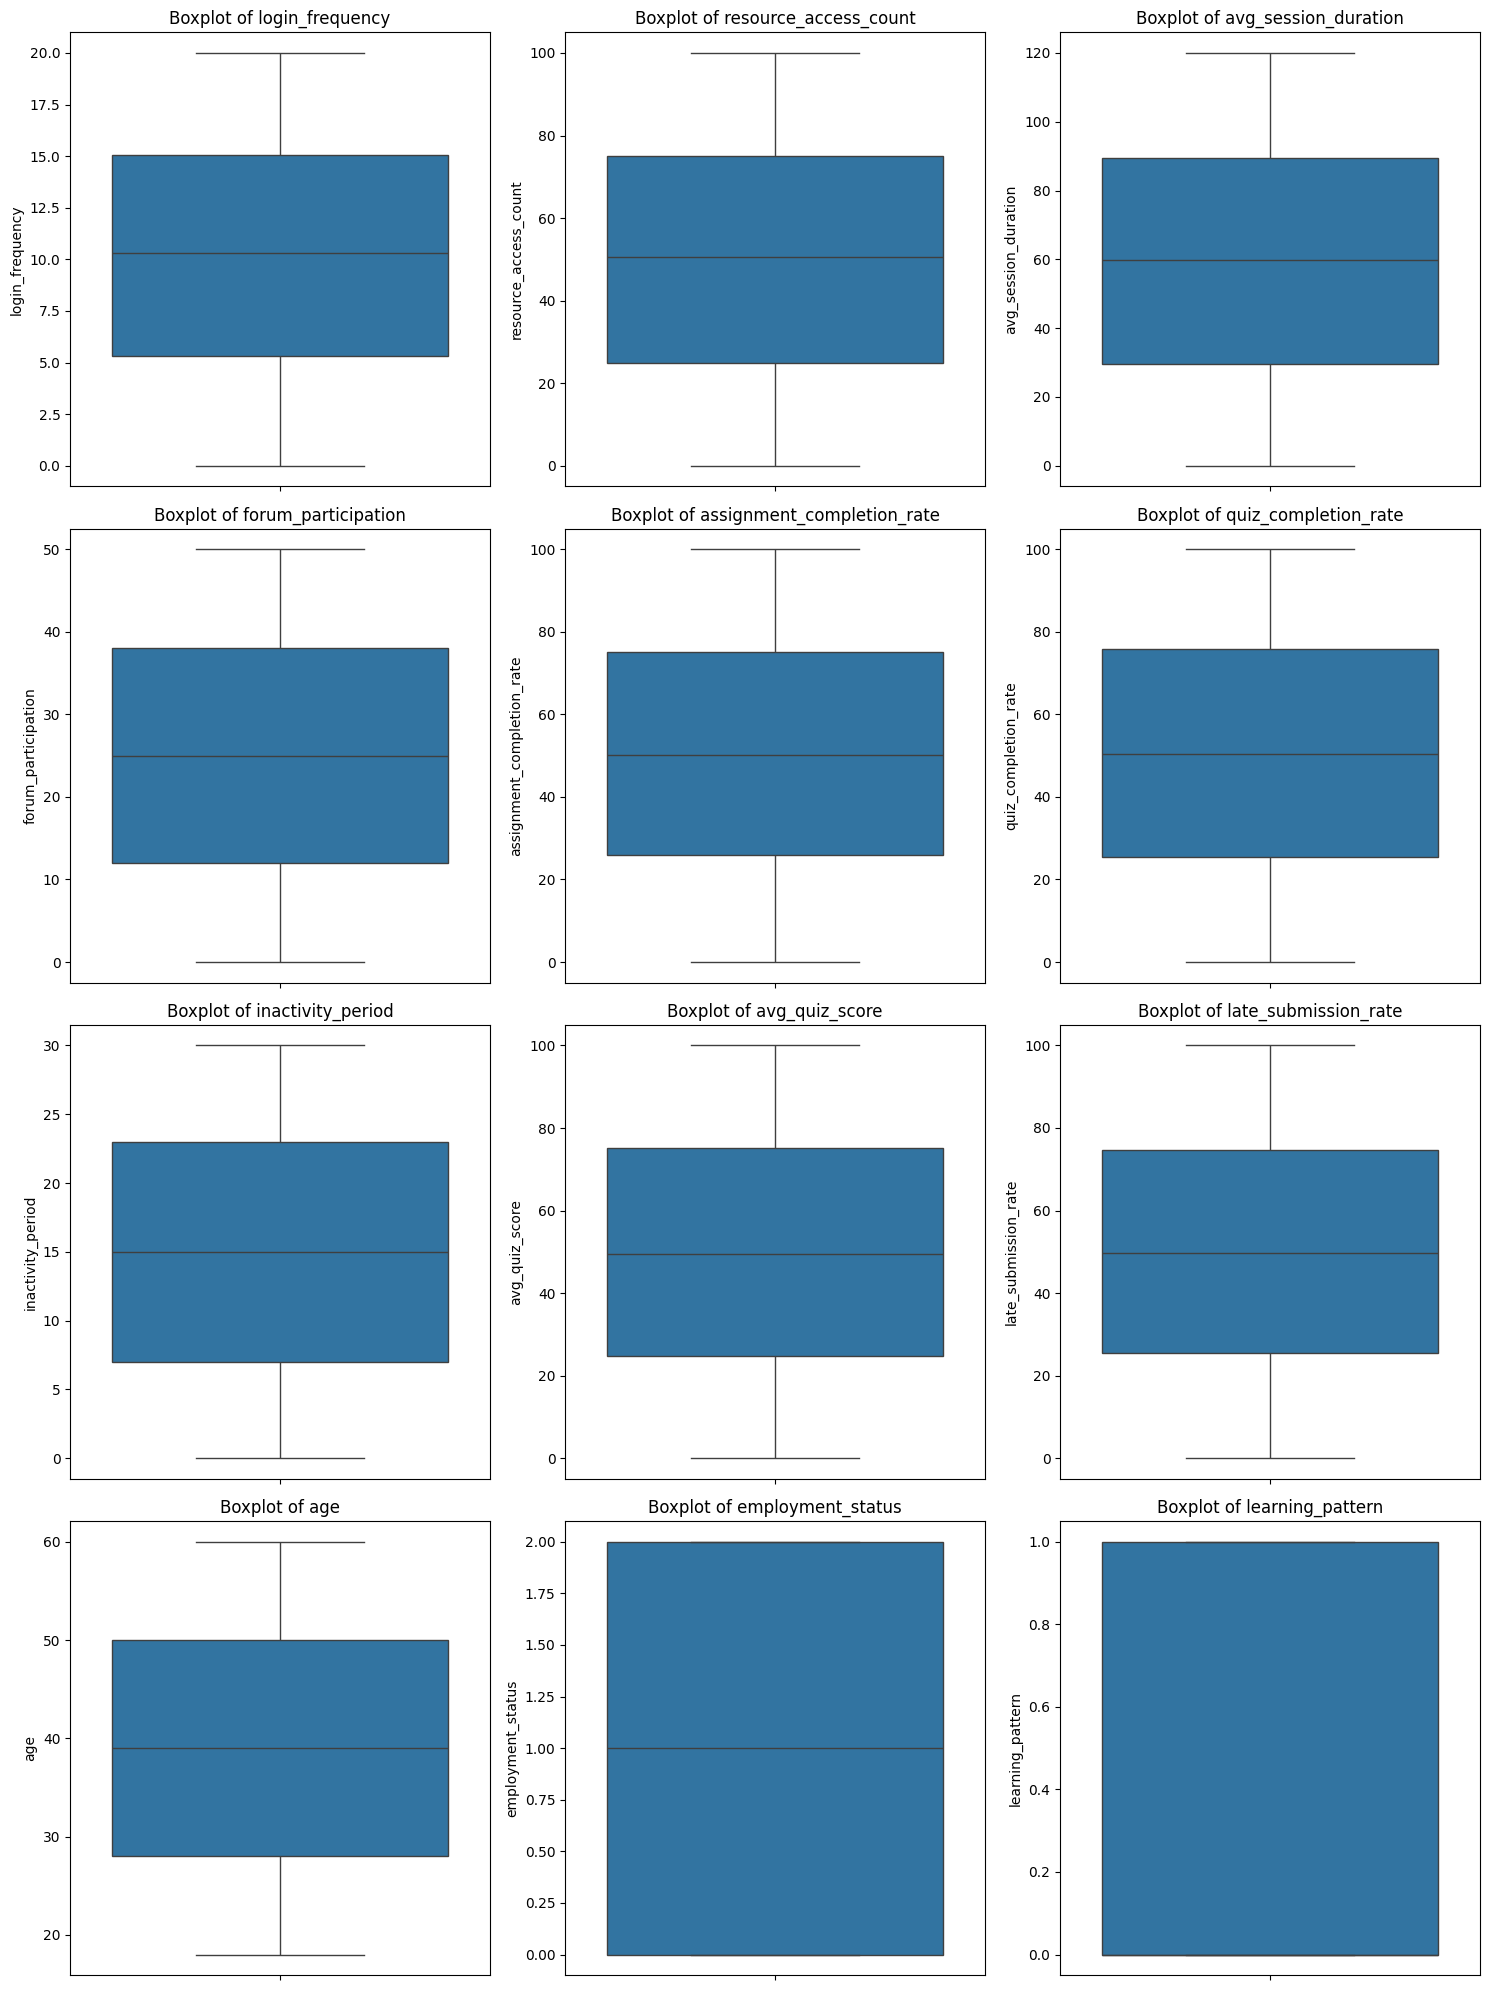

In [ ]:
# Thiết lập kích thước và bố cục subplot
n_cols = 3
n_rows = (len(numerical_cols) + n_cols - 1) // n_cols
plt.figure(figsize=(15, 5 * n_rows))
# Vẽ boxplot cho từng cột số
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')
    plt.ylabel(col)

# Điều chỉnh bố cục và lưu hình ảnh
plt.tight_layout()
plt.show()

# **III. EDA**

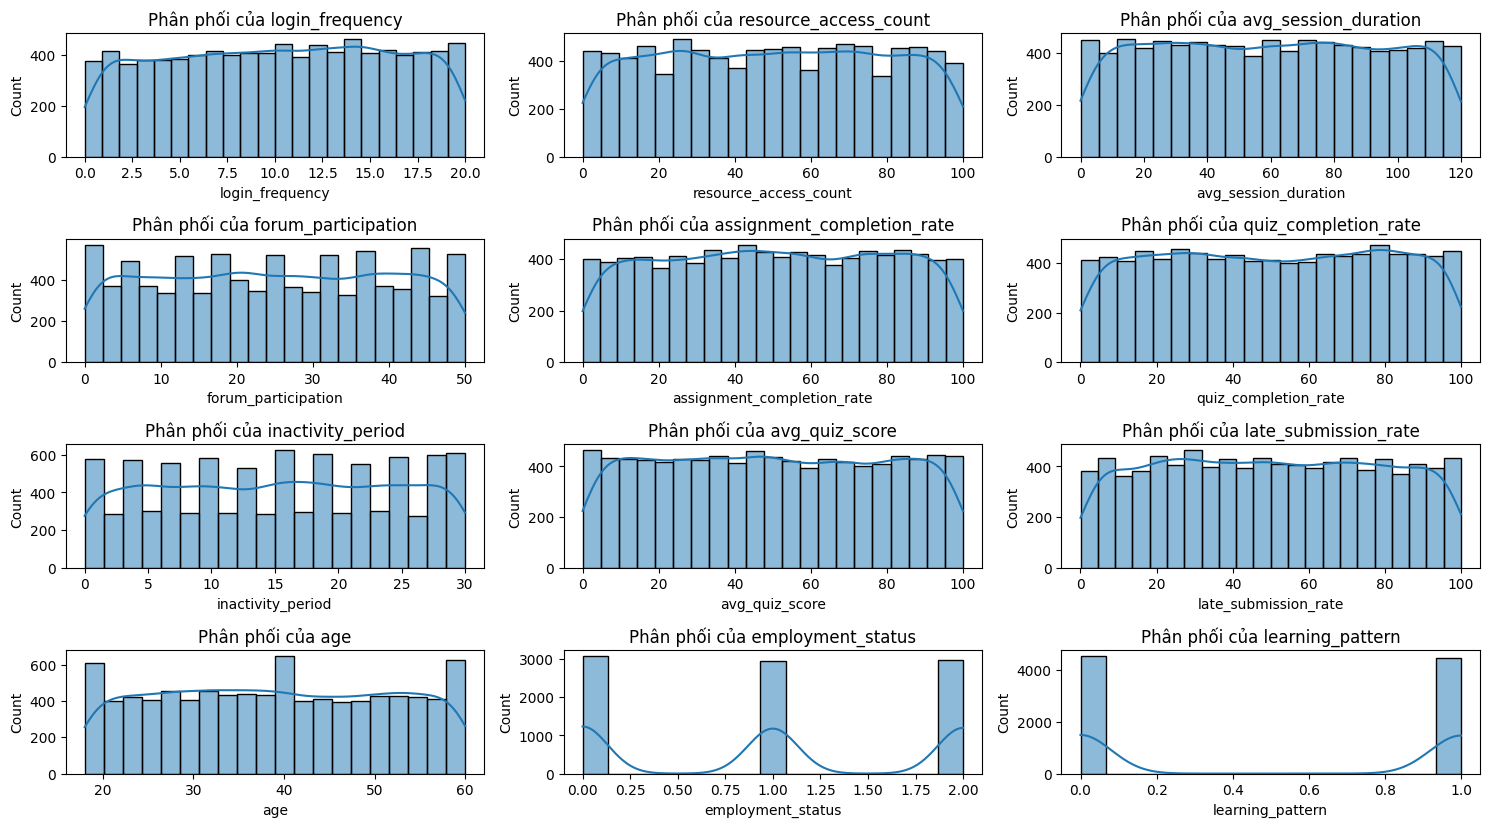

In [ ]:
#Phân phối cột số (Histogram)
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.drop(['dropout'])
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols, 1):#
    plt.subplot(5, 3, i)
    sns.histplot(df[col], kde=True)
    plt.title(f'Phân phối của {col}')
plt.tight_layout()
plt.show()

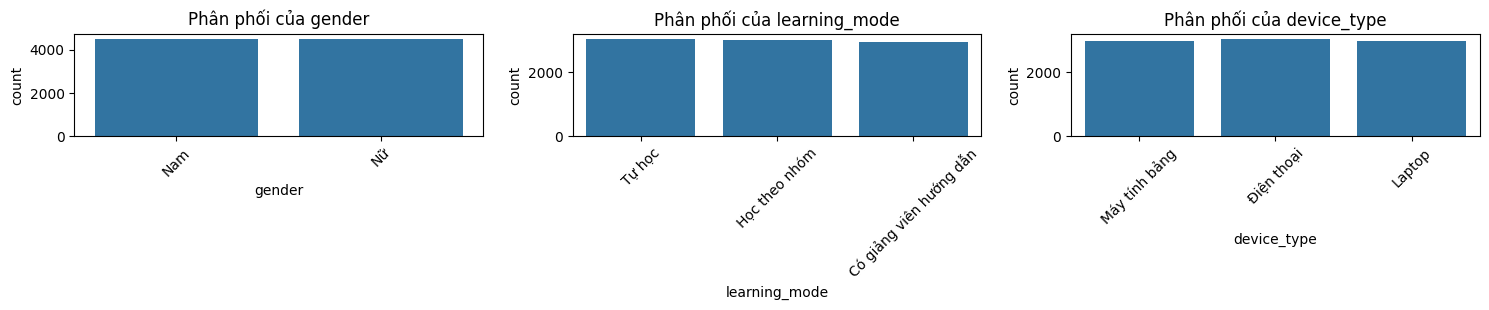

In [ ]:
#Phân phối của các cột phân loại
categorical_cols = df.select_dtypes(include=['object']).columns.drop(['learner_id'])
plt.figure(figsize=(15, 10))
for i, col in enumerate(categorical_cols, 1):
    plt.subplot(4, 3, i)
    sns.countplot(data=df, x=col)
    plt.title(f'Phân phối của {col}')
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

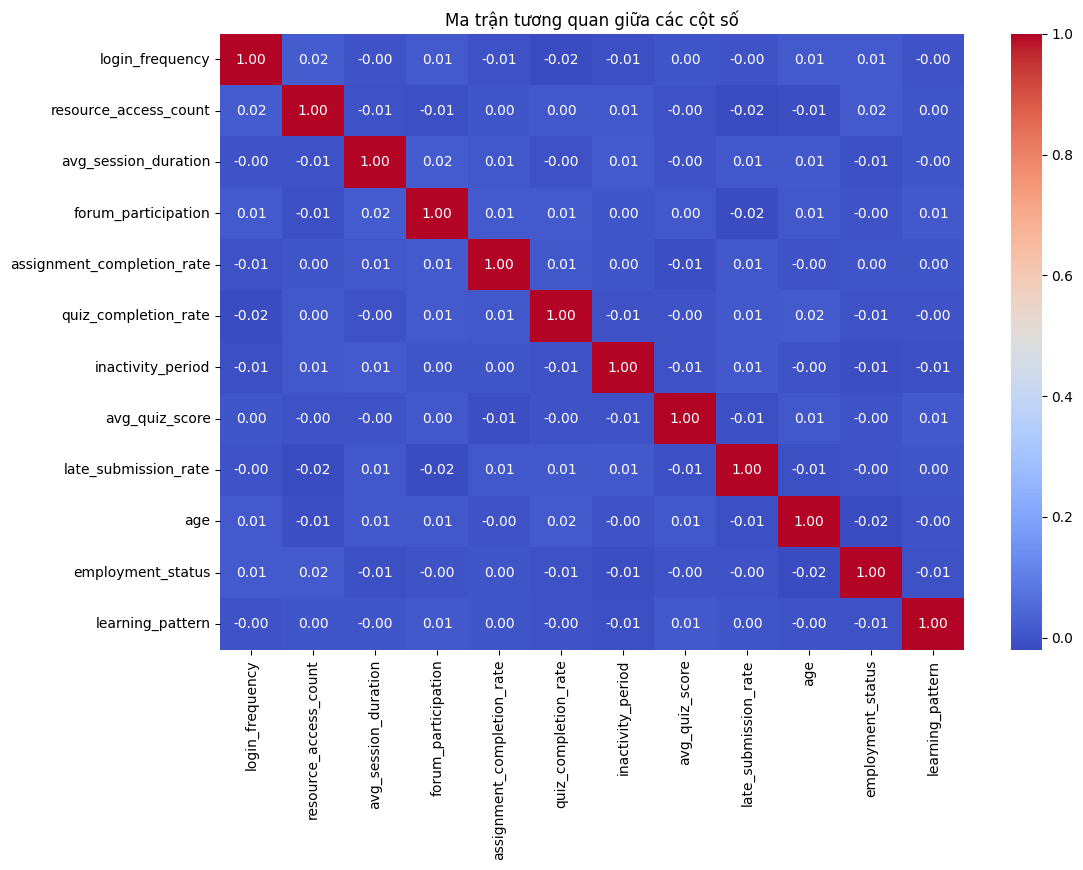

In [ ]:
# Ma trận tương quan
plt.figure(figsize=(12, 8))
correlation_matrix = df[numerical_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Ma trận tương quan giữa các cột số')
plt.savefig('correlation_matrix.png')
plt.show()

# **III.PHÂN CỤM K-MEANS**

**1. LỰA CHỌN ĐẶC TRƯNG VÀ CHUẨN HOÁ DỮ LIỆU**

In [ ]:
# Lựa chọn đặc trưng
selected_features = ['assignment_completion_rate', 'quiz_completion_rate'	, 'avg_quiz_score']
features_df = df[selected_features]

In [ ]:
# Chuẩn hóa dữ liệu
X = MinMaxScaler().fit_transform(features_df)
# Chuyển sang DataFrame
X_scaled = pd.DataFrame(X, columns=['assignment_completion_rate', 'quiz_completion_rate'	, 'avg_quiz_score'])
df_minmax = X_scaled.copy()

In [ ]:
X_scaled.head()

,assignment_completion_rate,quiz_completion_rate,avg_quiz_score
0,0.709865,0.870108,0.764791
1,0.892655,0.019499,0.612703
2,0.690842,0.420015,0.080607
3,0.416605,0.960513,0.118466
4,0.513670,0.177141,0.481169


**2. TÌM K CỤM TỐI ƯU**

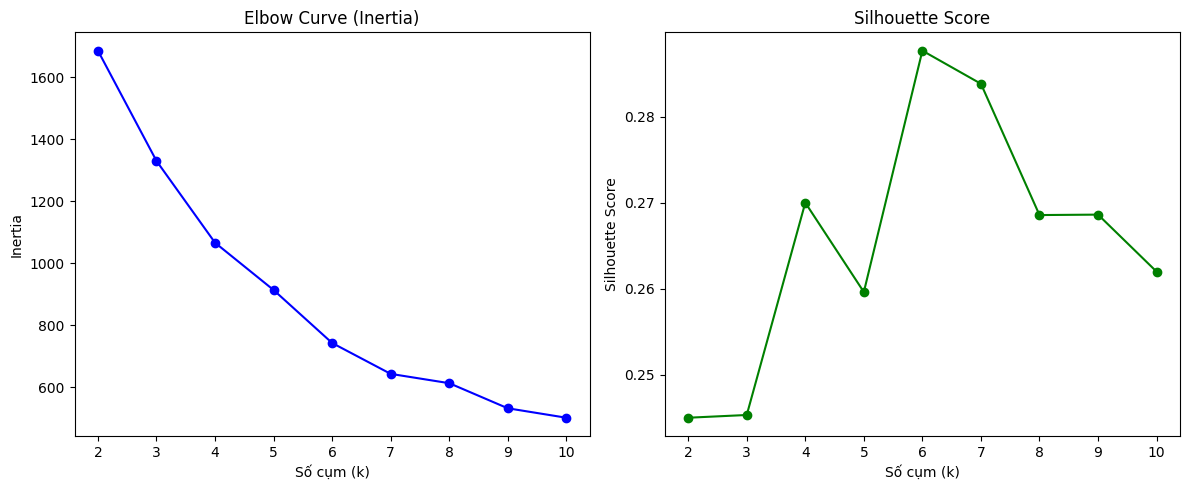

In [ ]:
# Thử các số cụm từ 2 đến 10
cluster_range = range(2, 11)
inertia_values = []
silhouette_scores = []

for n_clusters in cluster_range:
    kmeans = KMeans(n_clusters=n_clusters, init='k-means++', random_state=42)
    kmeans.fit(X)
    inertia_values.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# Vẽ biểu đồ Elbow và Silhouette
plt.figure(figsize=(12, 5))

# Elbow Curve
plt.subplot(1, 2, 1)
plt.plot(cluster_range, inertia_values, marker='o', color='blue')
plt.title('Elbow Curve (Inertia)')
plt.xlabel('Số cụm (k)')
plt.ylabel('Inertia')

# Silhouette Score
plt.subplot(1, 2, 2)
plt.plot(cluster_range, silhouette_scores, marker='o', color='green')
plt.title('Silhouette Score')
plt.xlabel('Số cụm (k)')
plt.ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

**3. ĐÁNH GIÁ CHẤT LƯỢNG PHÂN CỤM**

In [ ]:
# Phân cụm KMeans
k = 6
kmeans_model = KMeans(n_clusters=k, init='k-means++', random_state=42)
cluster_labels = kmeans_model.fit_predict(X_scaled)

# Tạo DataFrame chứa nhãn cụm
cluster_df = features_df.copy()
cluster_df['cluster'] = cluster_labels
df['cluster']= cluster_labels

# Thống kê số lượng phần tử trong mỗi cụm
print("Số lượng phần tử trong mỗi cụm:")
print(cluster_df['cluster'].value_counts())

# 5. Các chỉ số đánh giá chất lượng phân cụm:

# WSS (Within-Cluster Sum of Squares) - Càng nhỏ càng tốt
wss = kmeans_model.inertia_
print("Within-Cluster Sum of Squares (WSS):", wss)

# BSS (Between-Cluster Sum of Squares)
centroids = kmeans_model.cluster_centers_
mean = features_df.mean(axis=0)  # Tính giá trị trung bình của các đặc trưng

bss = 0
for centroid in centroids:
    bss += np.sum((centroid - mean) ** 2)

print("Between-Cluster Sum of Squares (BSS):", bss)

# Silhouette Score (Điểm càng gần 1 càng tốt, càng gần -1 càng tệ)
sil_avg = silhouette_score(X_scaled, cluster_labels)
print("Silhouette Score:", sil_avg)

# Calinski Harabasz Score (Điểm cao hơn cho thấy phân cụm tốt hơn)
calinski_harabasz_score_val = calinski_harabasz_score(X_scaled, cluster_labels)
print("Calinski Harabasz Score:", calinski_harabasz_score_val)

# Davies-Bouldin Index
davies_bouldin = davies_bouldin_score(X_scaled, cluster_labels)
print("Davies-Bouldin Index:",davies_bouldin)


Số lượng phần tử trong mỗi cụm:
cluster
4    1543
2    1538
0    1505
3    1490
5    1477
1    1447
Name: count, dtype: int64
Within-Cluster Sum of Squares (WSS): 743.2147729496618
Between-Cluster Sum of Squares (BSS): 44428.5223261334
Silhouette Score: 0.28766256594687717
Calinski Harabasz Score: 3660.952166375992
Davies-Bouldin Index: 0.9657092572532299


In [ ]:
cluster_df.groupby("cluster")
cluster_df.head(20)

,assignment_completion_rate,quiz_completion_rate,avg_quiz_score,cluster
0,70.980378,87.002316,76.474338,1
1,89.254519,1.954311,61.269420,0
2,69.078629,41.999831,8.073264,5
3,41.662303,96.041406,11.858173,5
4,51.366122,17.716174,48.119323,0
5,71.232580,65.372736,85.283846,1
6,61.328189,79.019320,55.374821,1
7,52.946753,93.360452,91.961577,1
8,23.679248,87.179749,81.565259,2
9,61.696092,67.658124,63.078363,1


**4. TRỰC QUAN HOÁ CỤM**

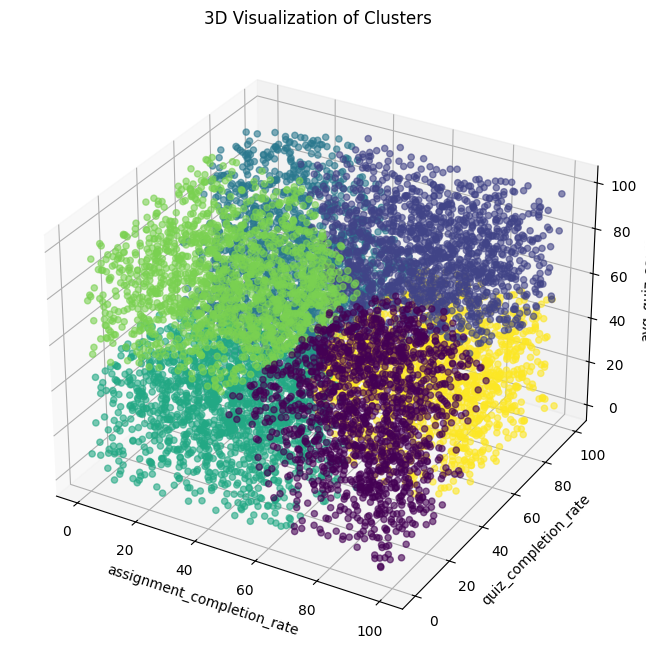

In [ ]:
# Trưc quan bằng biểu đồ 3D
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(cluster_df['assignment_completion_rate'], cluster_df['quiz_completion_rate'], cluster_df['avg_quiz_score'], c=cluster_df['cluster'], cmap='viridis', alpha=0.6)
ax.set_xlabel('assignment_completion_rate')
ax.set_ylabel('quiz_completion_rate')
ax.set_zlabel('avg_quiz_score')

ax.set_title('3D Visualization of Clusters')
plt.savefig('cluster_visualization_3d.png')
plt.show()

**5. PHÂN PHỐI DỮ LIỆU**

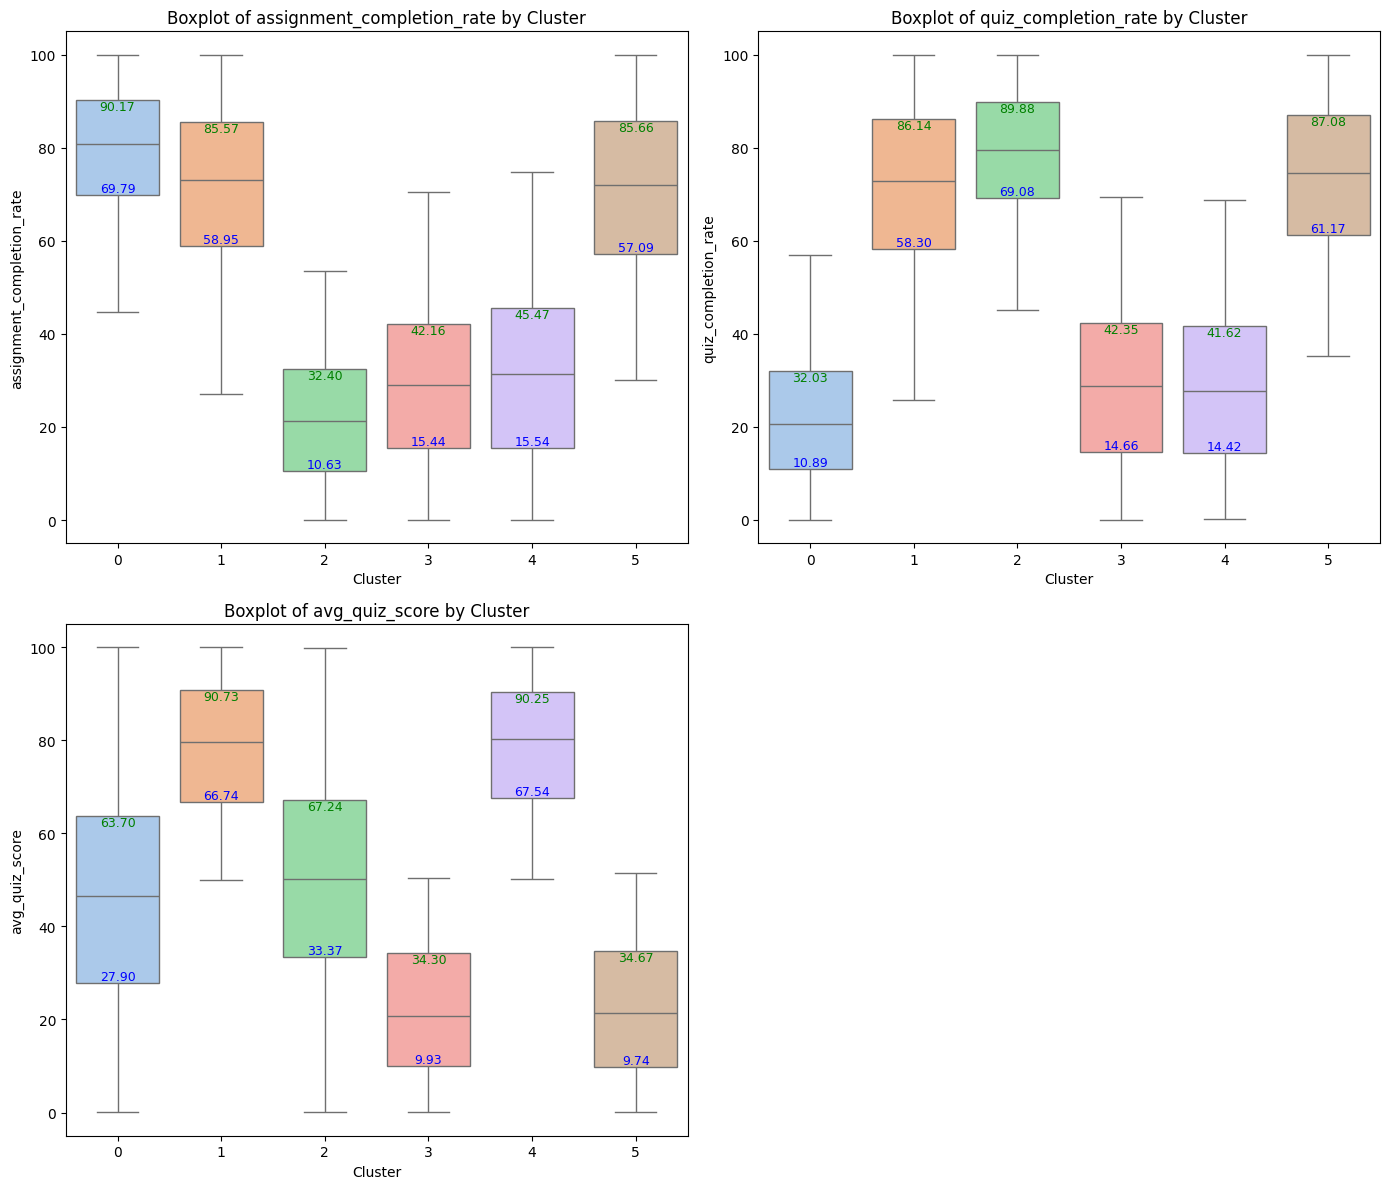

In [ ]:
# Danh sách các feature cần vẽ boxplot
features = ['assignment_completion_rate', 'quiz_completion_rate', 'avg_quiz_score']

# Số biểu đồ trên một hàng
plots_per_row = 2
n_rows = (len(features) + plots_per_row - 1) // plots_per_row

fig, axes = plt.subplots(n_rows, plots_per_row, figsize=(14, 6 * n_rows))

# Nếu chỉ có 1 hàng, axes là 1D; nếu nhiều hàng, flatten về 1D để duyệt dễ
axes = axes.flatten()

for idx, feature in enumerate(features):
    ax = axes[idx]

    # Vẽ boxplot
    sns.boxplot(data=cluster_df, x='cluster', y=feature, palette='pastel', hue='cluster', legend=False, ax=ax)

    # Tiêu đề và nhãn
    ax.set_title(f'Boxplot of {feature} by Cluster')
    ax.set_xlabel('Cluster')
    ax.set_ylabel(feature)

    # Thêm nhãn Q1 và Q3
    clusters = sorted(cluster_df['cluster'].unique())
    for i, cluster in enumerate(clusters):
        stats = cluster_df[cluster_df['cluster'] == cluster][feature].describe()
        q1 = stats['25%']
        q3 = stats['75%']
        ax.text(i, q1, f"{q1:.2f}", ha="center", va="bottom", fontsize=9, color='blue')
        ax.text(i, q3, f"{q3:.2f}", ha="center", va="top", fontsize=9, color='green')

# Ẩn subplot thừa nếu có
for j in range(len(features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


**6. ĐẶT TÊN CỤM**

In [ ]:
# Tính toán trung bình cho mỗi cụm
cluster_summary = cluster_df.groupby('cluster').mean().reset_index()
print("\nĐặc điểm trung bình của mỗi cụm:")
cluster_summary


Đặc điểm trung bình của mỗi cụm:


,cluster,assignment_completion_rate,quiz_completion_rate,avg_quiz_score
0,0,79.448640,21.902135,46.125580
1,1,71.820127,71.654005,78.275460
2,2,21.856277,78.851177,50.345281
3,3,29.083202,28.991209,22.282860
4,4,31.040394,28.287270,78.667675
5,5,70.979191,73.664634,22.689819


Cluster:
- 0: "Nhóm tập trung vào bài tập nhưng thiếu tương tác đánh giá"
- 1: "Nhóm học tập tích cực toàn diện"
- 2: "Nhóm thiên lệch đánh giá, bỏ qua quá trình"
- 3: "Nhóm thụ động với tỷ lệ tham gia thấp"
- 4: "Nhóm hiệu suất cao nhưng tham gia hạn chế"
- 5: "Nhóm chăm chỉ nhưng hiệu quả thấp"



In [ ]:
cluster_names = {
    0: "Học viên thụ động có tiềm năng",
    1: "Học viên xuất sắc",
    2: "Ưu tiên kiểm tra",
    3: "Học viên yếu, cần hỗ trợ",
    4: "NNăng lực cao – cam kết thấp",
    5: "Chăm chỉ nhưng chưa hiệu quả"
}
df['learning_behavior'] = df['cluster'].map(cluster_names)
df = df.drop(columns=['cluster'])
pd.set_option('display.max_columns', None)
df.head()

,learner_id,gender,learning_mode,device_type,login_frequency,resource_access_count,avg_session_duration,forum_participation,assignment_completion_rate,quiz_completion_rate,inactivity_period,avg_quiz_score,late_submission_rate,age,employment_status,learning_pattern,dropout,learning_behavior
0,H0001,Nam,Tự học,Máy tính bảng,7.448474,29,75.592809,7,70.980378,87.002316,25,76.474338,2.330537,49,1,0,0,Học viên xuất sắc
1,H0002,Nữ,Tự học,Điện thoại,15.798234,12,94.330348,18,89.254519,1.954311,18,61.269420,1.964830,27,2,1,0,Học viên thụ động có tiềm năng
2,H0003,Nam,Học theo nhóm,Máy tính bảng,0.786390,14,95.988471,9,69.078629,41.999831,19,8.073264,43.684065,51,2,1,1,Chăm chỉ nhưng chưa hiệu quả
3,H0004,Nam,Tự học,Máy tính bảng,8.635351,19,102.121509,32,41.662303,96.041406,26,11.858173,92.420582,22,0,1,1,Chăm chỉ nhưng chưa hiệu quả
4,H0005,Nam,Học theo nhóm,Điện thoại,7.645118,33,31.999654,36,51.366122,17.716174,22,48.119323,76.811934,37,0,1,1,Học viên thụ động có tiềm năng


**7. PHÂN PHỐI CỤM**

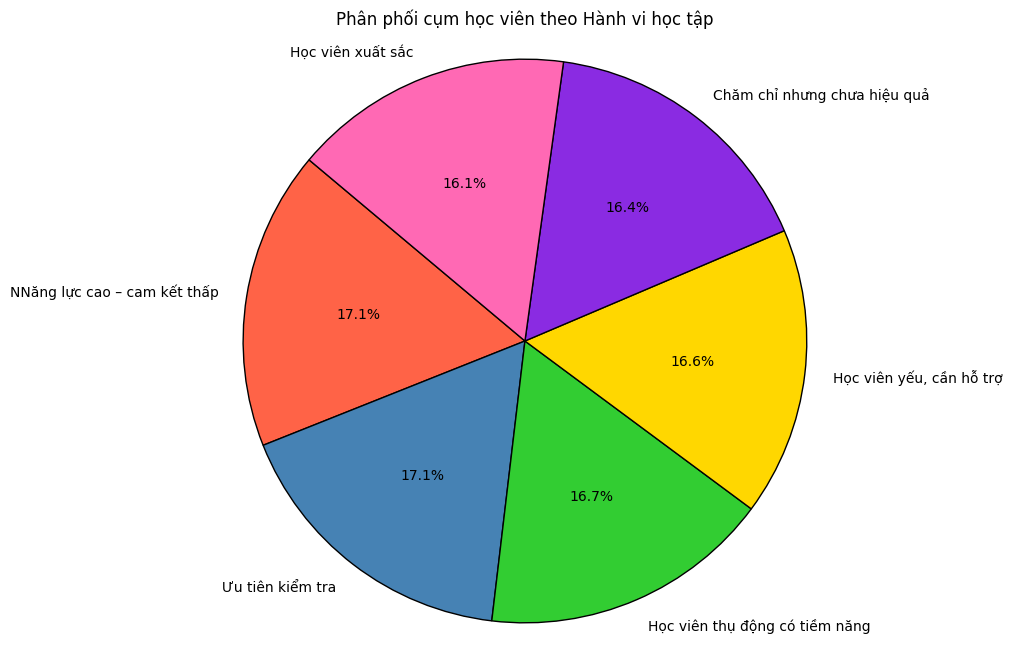

In [ ]:
# Đếm số lượng mẫu trong từng cụm
cluster_counts = df['learning_behavior'].value_counts()

# Vẽ biểu đồ Pie
plt.figure(figsize=(8, 8))
plt.pie(
    cluster_counts,
    labels=cluster_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=['#FF6347', '#4682B4', '#32CD32', '#FFD700', '#8A2BE2', '#FF69B4'] ,
    wedgeprops={'edgecolor': 'black'}
)

plt.title('Phân phối cụm học viên theo Hành vi học tập')
plt.axis('equal')
plt.show()

# **V. PHÂN CỤM HIERARCHICAL**

**1. TÍNH MA TRẬN KHOẢNG CÁCH**

In [ ]:
from scipy.spatial.distance import pdist

distance_matrix = pdist(df_minmax, metric='euclidean')

In [ ]:
distance_matrix

array([0.88322133, 0.81917858, 0.715479  , ..., 0.67118818, 0.69947438,
       0.39462276])

**2. XÂY DỰNG CÂY PHÂN CỤM**

In [ ]:
from scipy.cluster.hierarchy import linkage

linkage_matrix = linkage(distance_matrix, method='ward')

**3. BIỂU DIỄN CẤU TRÚC CÂY PHÂN CỤM**





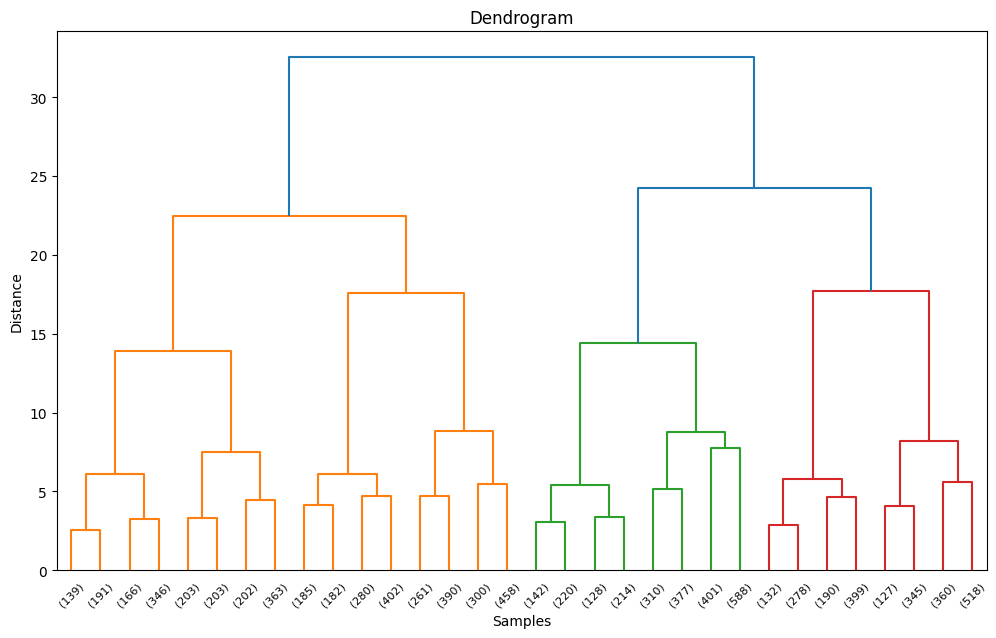

In [ ]:
from scipy.cluster.hierarchy import dendrogram

plt.figure(figsize=(12, 7))
dendrogram(linkage_matrix, truncate_mode='level', p=4)
plt.title("Dendrogram")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()

**4. TRỰC QUAN HOÁ CỤM**

   assignment_completion_rate  quiz_completion_rate  avg_quiz_score  Cluster
0                   70.980378             87.002316       76.474338        3
1                   89.254519              1.954311       61.269420        2
2                   69.078629             41.999831        8.073264        4
3                   41.662303             96.041406       11.858173        6
4                   51.366122             17.716174       48.119323        1


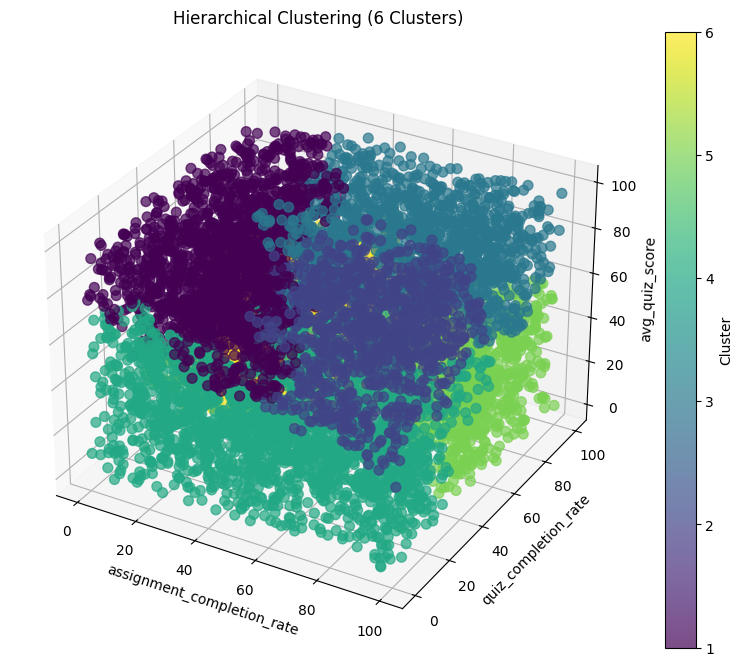

In [ ]:
from scipy.cluster.hierarchy import fcluster
clusters = fcluster(linkage_matrix, t=6, criterion='maxclust')

data['Cluster'] = clusters
print(data[['assignment_completion_rate', 'quiz_completion_rate'	, 'avg_quiz_score', 'Cluster']].head())

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    df['assignment_completion_rate'],
    df['quiz_completion_rate'],
    df['avg_quiz_score'],
    c=data['Cluster'], cmap='viridis', s=50, alpha=0.7)

ax.set_xlabel('assignment_completion_rate')
ax.set_ylabel('quiz_completion_rate')
ax.set_zlabel('avg_quiz_score')

ax.set_title('Hierarchical Clustering (6 Clusters)')
plt.colorbar(scatter, label='Cluster')
plt.show()

**5. PHÂN PHỐI DỮ LIỆU**

In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px

# Thống kê số lượng phần tử trong mỗi cụm
print("Số lượng phần tử trong mỗi cụm:")
print(data['Cluster'].value_counts())

features = ['assignment_completion_rate', 'quiz_completion_rate', 'avg_quiz_score']

# Tạo figure với 2 hàng, 2 cột
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=[f'Boxplot of {feature} by Cluster' for feature in features]
)

# Mapping từng feature vào đúng vị trí (row, col)
positions = [(1, 1), (1, 2), (2, 1)]

for i, (feature, (row, col)) in enumerate(zip(features, positions)):
    boxplot = px.box(data, x='Cluster', y=feature)
    for trace in boxplot.data:
        fig.add_trace(trace, row=row, col=col)

fig.update_layout(
    title="Boxplots of Features by Cluster",
    showlegend=False,
    height=700,
    width=900
)

fig.show()


Số lượng phần tử trong mỗi cụm:
Cluster
4    2380
1    1813
3    1409
6    1350
2    1049
5     999
Name: count, dtype: int64


**6. ĐÁNH GIÁ CHẤT LƯỢNG PHÂN CỤM**

In [ ]:
# Các chỉ số đánh giá chất lượng phân cụm
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
silhouette_avg = silhouette_score(df_minmax, clusters)
calinski_harabasz = calinski_harabasz_score(df_minmax, clusters)
davies_bouldin = davies_bouldin_score(df_minmax, clusters)

print(f"Silhouette Score: {silhouette_avg:.3f}")
print(f"Calinski-Harabasz Score): {calinski_harabasz:.3f}")
print(f"Davies-Bouldin Index): {davies_bouldin:.3f}")

Silhouette Score: 0.222
Calinski-Harabasz Score): 3058.153
Davies-Bouldin Index): 1.101


In [ ]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import numpy as np

# Dữ liệu đã chuẩn hóa và labels phân cụm
X = df_minmax.values
labels = data['Cluster'].values
unique_labels = np.unique(labels)
overall_mean = np.mean(X, axis=0)

# Silhouette, Calinski-Harabasz, Davies-Bouldin
silhouette_avg = silhouette_score(X, labels)
calinski_harabasz = calinski_harabasz_score(X, labels)
davies_bouldin = davies_bouldin_score(X, labels)

# WSS (Within-Cluster Sum of Squares)
wss = 0
for k in unique_labels:
    cluster_k = X[labels == k]
    centroid_k = np.mean(cluster_k, axis=0)
    wss += np.sum((cluster_k - centroid_k) ** 2)

# BSS (Between-Cluster Sum of Squares)
bss = 0
for k in unique_labels:
    cluster_k = X[labels == k]
    centroid_k = np.mean(cluster_k, axis=0)
    bss += len(cluster_k) * np.sum((centroid_k - overall_mean) ** 2)

# In kết quả
print(f"Within-Cluster Sum of Squares (WSS): {wss:.3f}")
print(f"Between-Cluster Sum of Squares (BSS): {bss:.3f}")
print(f"Silhouette Score: {silhouette_avg:.3f}")
print(f"Calinski-Harabasz Score: {calinski_harabasz:.3f}")
print(f"Davies-Bouldin Index: {davies_bouldin:.3f}")

Within-Cluster Sum of Squares (WSS): 667.262
Between-Cluster Sum of Squares (BSS): 1588.537
Silhouette Score: 0.222
Calinski-Harabasz Score: 3058.153
Davies-Bouldin Index: 1.101
